# Total effect of the FIFA sponsorship on Lenovo's brand

**Review notebook** for the project's headline estimate, `sponsorship_total_effect_v1` (ADR-0034, ADR-0035, ADR-0038), with the original 2024 design (`sponsorship_counterfactual_v1`) shown for context and its media-value weighting sensitivity (ADR-0028). It follows the human-review standard in `AGENTS.md`. A close-up on the World Cup is in `20_world_cup_close_up.ipynb`.

*How to use:* run all cells. The notebook only reads production outputs and imports production code; it never rewrites data unless `RUN_REBUILD` is set to `True` in the first code cell. Every number in the narrative is computed from the current outputs when the notebook runs.

In [1]:
# Setup: read-only by default (AGENTS.md). Nothing below rewrites data unless RUN_REBUILD is True.
RUN_REBUILD = False   # set True only to regenerate the production outputs this notebook reads

import json, os, subprocess, sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "srmp").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from srmp.review import stamp_sources

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
plt.rcParams.update({"figure.figsize": (10, 4.2), "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

def md(text):
    display(Markdown(text))

def fmt(value, digits=2, signed=False):
    return f"{value:+.{digits}f}" if signed else f"{value:.{digits}f}"

if RUN_REBUILD:  # explicit opt-in: regenerates the outputs read below (several minutes)
    for module in ["srmp.experiments.sponsorship_counterfactual_v1", "srmp.experiments.sponsorship_total_effect_v1"]:
        subprocess.run([sys.executable, "-m", module], check=True)

E = "data/curated/experimental/"
T = E + "sponsorship_total_effect_v1/"
SOURCES = [
    "data/curated/index/brand_index_weekly.parquet",
    "data/curated/trends/jointly_scaled_donor_trends.parquet",
    "data/curated/trends/trends_weekly_averaged.parquet",
    "data/reference/counterfactual_donor_registry.csv",
    "config/experiments/sponsorship_total_effect_v1.yaml",
    T + "selection_record.json", T + "selection_table.parquet", T + "estimate_manifest.json",
    T + "total_effect_weekly.parquet", T + "donor_sensitivity.parquet", T + "specification_curve.parquet",
    E + "sponsorship_counterfactual_v1/counterfactual_manifest.json",
    E + "sponsorship_counterfactual_v1/media_value_intensity_sensitivity.json",
]
stamp_sources(SOURCES)
est = json.loads(Path(T + "estimate_manifest.json").read_text())
effect, p = est["total_effect"], est["primary"]

REVIEW_SOURCES={"data/curated/index/brand_index_weekly.parquet": "5acb22608f2dbbd19acd50d3f1378dd7f3f92e957dcb282c2e729c5fe5ee4449", "data/curated/trends/jointly_scaled_donor_trends.parquet": "d03dea0cf14b0af202f704502829d0801ba2763df187b0be17881f1309aaf4a7", "data/curated/trends/trends_weekly_averaged.parquet": "6b114d3b23ba37aa4cbacb6e8e7ba21cf469f73537454ece108ae10690b37134", "data/reference/counterfactual_donor_registry.csv": "d3e93f01eeca4b42c4f6cfb0734b6ff10687e83014cbc8633f40b3d157972475", "config/experiments/sponsorship_total_effect_v1.yaml": "5da231fba764922b5d922f35ff41e9cd7ebb81900b6179c6ac59dad9e37a84e9", "data/curated/experimental/sponsorship_total_effect_v1/selection_record.json": "08dc3256f200506bd6219588434631eb5a103e4ef48f810fd33973a8eff0e6ee", "data/curated/experimental/sponsorship_total_effect_v1/selection_table.parquet": "106cac036e7bbf31471269e3bbfc7dbf86aa9e6cdd4a824fcf8286a810322729", "data/curated/experimental/sponsorship_total_effect_v1/estimate_manifest.json":

## 1. Question and purpose

**Question.** Over the whole sponsorship so far, from the partnership announcement on 15 October 2024 through the 2026 World Cup and the weeks after it, how much higher is Lenovo's brand salience than it would have been without the FIFA sponsorship?

**Why it matters.** This is the project's headline brand effect. Valuation and any return-on-sponsorship estimate are built on it. The World Cup is part of this period, not a separate claim; it is examined in close-up in notebook 20.

**Objective supported.** Measuring the sponsorship's total brand uplift before any monetisation.

## 2. Evidence and inputs

| Input | What it is | Source | Label |
|---|---|---|---|
| Lenovo Brand Index | Weekly brand-salience index on a 100/15 display scale. Weekly movement comes 100% from worldwide Google Trends interest in "Lenovo"; GWI survey waves only orient and scale it | Google Trends; GWI | **constructed** (proxy-led index) |
| Rival ("donor") brands | Weekly Google Trends interest for 26 screened rival tech brands, pulled in panels sharing a "Lenovo" anchor so all sit on one scale | Google Trends | **observed**, then **constructed** (common-anchor rescaling) |
| Donor registry | Which brands may serve as comparisons, after screening for FIFA/World Cup sponsorship and data quality | FIFA partner lists, brand news, our screen | **assumed** (evidence-bounded) |
| Media value | Vendor media-equivalency by FIFA competition and market, used only as a relative weight in a sensitivity | Client export | **estimated** by the vendor |

In [2]:
index = pd.read_parquet("data/curated/index/brand_index_weekly.parquet")
donors = pd.read_parquet("data/curated/trends/jointly_scaled_donor_trends.parquet")
registry = pd.read_csv("data/reference/counterfactual_donor_registry.csv")
weekly = pd.read_parquet(T + "total_effect_weekly.parquet"); weekly["week"] = pd.to_datetime(weekly["week"])
display(pd.DataFrame([
    {"Input": "Lenovo Brand Index (weeks)", "First": str(index["week"].min()), "Last": str(index["week"].max()), "Count": len(index)},
    {"Input": "Donor panels (Trends weeks)", "First": str(donors["week"].min())[:10], "Last": str(donors["week"].max())[:10], "Count": donors["query_id"].nunique()},
    {"Input": "Estimation panel (provisional weeks excluded)", "First": str(weekly["week"].min().date()), "Last": str(weekly["week"].max().date()), "Count": len(weekly)},
]).rename(columns={"Count": "Weeks (donor panels: queries)"}))
display(registry["inclusion_policy"].value_counts().rename_axis("Donor registry policy").rename("Brands").to_frame())

,Input,First,Last,Weeks (donor panels: queries)
0,Lenovo Brand Index (weeks),2022-01-03,2026-09-28,248
1,Donor panels (Trends weeks),2021-12-26,2026-09-27,38
2,Estimation panel (provisional weeks excluded),2022-01-03,2026-09-14,246


,Brands
Donor registry policy,
candidate_base,15
base,11
data_quality_excluded,7
excluded,2
sensitivity,2


**Reading the registry.** `base`: screened clean in July 2026 (ADR-0021); `candidate_base`: added and screened in October 2026 (ADR-0035); `sensitivity`: used only in robustness checks; `excluded`: FIFA or World Cup activity found; `data_quality_excluded`: mostly empty or constant search series before the announcement.

## 3. Method and formulas

**Synthetic control.** Lenovo cannot be observed without the sponsorship, so a "synthetic Lenovo" is built from a weighted mix of rival brands that tracked Lenovo closely *before* the announcement; its later path stands in for Lenovo without the sponsorship.

All series are standardised with their own pre-announcement mean and standard deviation, so post-announcement data never influence scaling. For Lenovo $y_t$ and donors $x_{jt}$ in these units, the simplex weights solve

$$\hat w = \arg\min_{w} \sum_{t < T_0} \Big(y_t - \sum_j w_j x_{jt}\Big)^2 \quad \text{s.t. } w_j \ge 0,\ \sum_j w_j = 1 .$$

*In words:* the non-negative mix of rival brands, adding to 100%, that best reproduces Lenovo before $T_0$ = 21 October 2024 (first full week after the announcement).

The weekly **gap** in Brand Index points, and the **total effect**:

$$\text{gap}_t = \sigma_y \Big(y_t - \sum_j \hat w_j x_{jt}\Big), \qquad \text{Total effect} = \frac{1}{|P|}\sum_{t \in P} \text{gap}_t ,$$

where $\sigma_y$ is Lenovo's pre-announcement standard deviation in Index points and $P$ is every week from $T_0$ to the latest non-provisional week. *In words:* the average amount by which Lenovo sits above its no-sponsorship twin over the sponsorship so far.

**Placebo test (pre-registered).** Each rival is treated as if it had been sponsored, with its own twin built from the other rivals. With the post/pre RMSPE ratio $R = \sqrt{\overline{\text{gap}^2}_{post}} / \sqrt{\overline{\text{gap}^2}_{pre}}$,

$$p = \frac{1 + \#\{\text{rivals with } R_j \ge R_{Lenovo}\}}{1 + J}.$$

*In words:* the share of rival brands that diverge from their own twins at least as much as Lenovo does. Threshold: $p \le 0.10$; with $J$ rivals the smallest possible $p$ is $1/(1+J)$.

**Design chosen on pre-period evidence only.** Twelve or more candidate designs (simplex SCM, augmented SCM, synthetic DiD, factor model × donor pools) predict Lenovo in four rolling 16-week pre-announcement folds; the lowest out-of-sample error wins. No post-announcement data enter the choice.

**Converting to salience.** The Index is an exact linear function of Lenovo's search interest, so a lift $\Delta$ over the no-sponsorship level $I_{cf}$ equals $\Delta / (I_{cf} - I_0)$ more search salience, where $I_0$ is the Index value at zero searches.

## 4. Calculation path

| Step | Reproducible code | Configuration | Output read here |
|---|---|---|---|
| Lenovo and donor Trends panels | `srmp/ingest/trends.py`, `srmp/ingest/trends_joint.py` | `config/queries_trends.yaml`, `config/joint_trends_donors.yaml` | `data/curated/trends/` |
| Brand Index | `srmp/index/proxy_led.py` | `config/base.yaml` | `data/curated/index/brand_index_weekly.parquet` |
| Design selection, total effect, placebos, weekly path, specification curve | `srmp/experiments/sponsorship_total_effect_v1.py` (`select_design`, `build`) with `srmp/counterfactual/scm.py` | `config/experiments/sponsorship_total_effect_v1.yaml` | `sponsorship_total_effect_v1/` |
| Original 2024 design and media-value sensitivity | `srmp/experiments/sponsorship_counterfactual_v1.py` | `config/experiments/sponsorship_counterfactual_v1.yaml` | `sponsorship_counterfactual_v1/` |
| Everything, in order | `python -m srmp.pipeline` | — | — |

## 5. Results

### 5.1 The headline: Lenovo vs its no-sponsorship twin

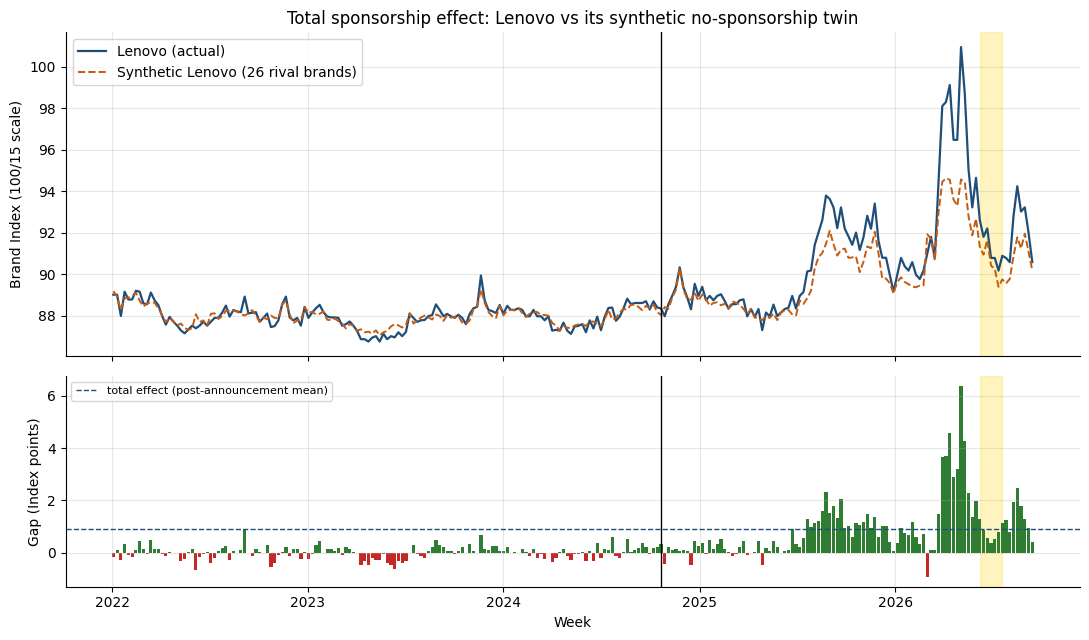

**Figure 1.** Vertical line: 2024-10-21, first full week after the announcement. Gold band: Men's World Cup. Pre-announcement fit error 0.25 Index points. Total effect over 100 weeks (2024-10-21 to 2026-09-14): **+0.91 Index points**.

In [3]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True, gridspec_kw={"height_ratios": [2, 1.3]})
ax1.plot(weekly["week"], weekly["actual_index"], label="Lenovo (actual)", color="#1f4e79", lw=1.6)
ax1.plot(weekly["week"], weekly["synthetic_index"], label=f"Synthetic Lenovo ({len(est['selection']['selected_donors'])} rival brands)",
         color="#c55a11", lw=1.4, ls="--")
for a in (ax1, ax2):
    a.axvline(pd.Timestamp(effect["first_post_week"]), color="black", lw=1)
    a.axvspan(pd.Timestamp("2026-06-08"), pd.Timestamp("2026-07-19"), color="gold", alpha=0.25)
ax1.set_ylabel("Brand Index (100/15 scale)"); ax1.set_title("Total sponsorship effect: Lenovo vs its synthetic no-sponsorship twin")
ax1.legend(loc="upper left")
ax2.bar(weekly["week"], weekly["index_gap"], width=6, color=np.where(weekly["index_gap"] >= 0, "#2e7d32", "#c62828"))
ax2.axhline(effect["lift_index_points"], color="#1f4e79", ls="--", lw=1, label="total effect (post-announcement mean)")
ax2.set_ylabel("Gap (Index points)"); ax2.set_xlabel("Week"); ax2.legend(loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()
md(f"**Figure 1.** Vertical line: {effect['first_post_week']}, first full week after the announcement. Gold band: Men's World Cup. "
   f"Pre-announcement fit error {fmt(p['pre_rmspe_index_points'])} Index points. Total effect over {effect['post_weeks']} weeks "
   f"({effect['first_post_week']} to {effect['last_week']}): **{fmt(effect['lift_index_points'], signed=True)} Index points**.")

In [4]:
phases = [("Before the announcement (fit period)", "2022-01-01", "2024-10-20"),
          ("Announcement quarter", "2024-10-21", "2024-12-31"), ("Early 2025", "2025-01-01", "2025-06-08"),
          ("Club World Cup 2025", "2025-06-09", "2025-07-13"), ("H2 2025 (U-17, U-20 World Cups)", "2025-07-14", "2025-12-31"),
          ("Q1 2026 (CES)", "2026-01-01", "2026-03-15"), ("Spring 2026 PC-price surge (confounded)", "2026-03-16", "2026-06-07"),
          ("Men's World Cup", "2026-06-08", "2026-07-19"), ("After the final", "2026-07-20", effect["last_week"]),
          ("TOTAL sponsorship period", effect["first_post_week"], effect["last_week"])]
table = pd.DataFrame([{"Period": name, "From": a, "To": b,
                       "Weeks": int(((weekly["week"] >= a) & (weekly["week"] <= b)).sum()),
                       "Mean gap (Index points)": weekly.loc[(weekly["week"] >= a) & (weekly["week"] <= b), "index_gap"].mean()}
                      for name, a, b in phases])
display(table.style.format({"Mean gap (Index points)": "{:+.2f}"}).hide(axis="index"))
md("**Table 1.** The total effect broken down by period (descriptive; only the total is tested). The lift builds over time rather than "
   "jumping at the announcement. The spring 2026 period coincides with a category-wide surge in PC-brand searches (section 5.5).")

Period,From,To,Weeks,Mean gap (Index points)
Before the announcement (fit period),2022-01-01,2024-10-20,146,+0.00
Announcement quarter,2024-10-21,2024-12-31,11,+0.07
Early 2025,2025-01-01,2025-06-08,22,+0.14
Club World Cup 2025,2025-06-09,2025-07-13,5,+0.33
"H2 2025 (U-17, U-20 World Cups)",2025-07-14,2025-12-31,25,+1.14
Q1 2026 (CES),2026-01-01,2026-03-15,10,+0.47
Spring 2026 PC-price surge (confounded),2026-03-16,2026-06-07,12,+2.98
Men's World Cup,2026-06-08,2026-07-19,6,+0.73
After the final,2026-07-20,2026-09-14,9,+1.33
TOTAL sponsorship period,2024-10-21,2026-09-14,100,+0.91


**Table 1.** The total effect broken down by period (descriptive; only the total is tested). The lift builds over time rather than jumping at the announcement. The spring 2026 period coincides with a category-wide surge in PC-brand searches (section 5.5).

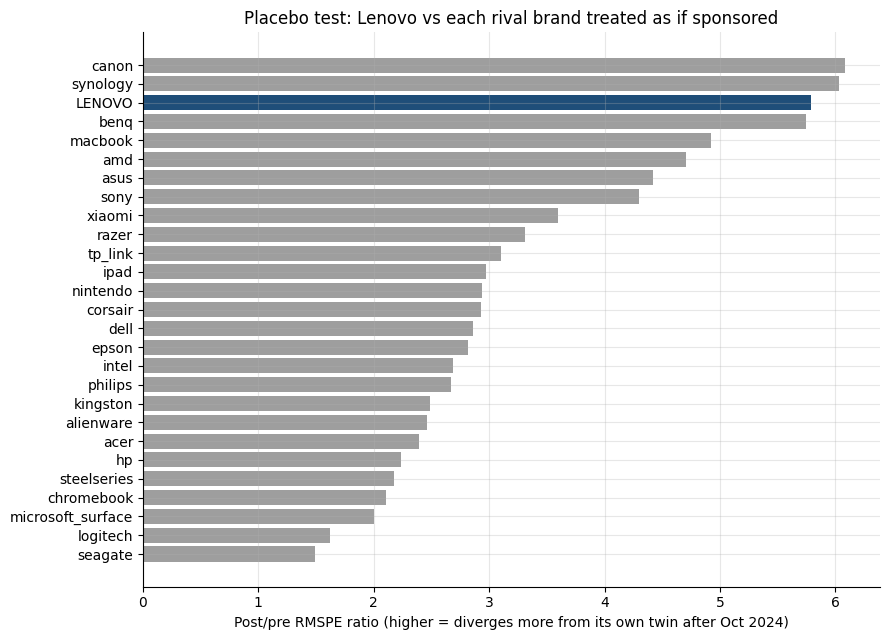

**Figure 2.** Rival brands diverging at least as much as Lenovo: synology, canon. p = **0.111** with 26 placebos (threshold 0.10; smallest possible 0.037). Result: **does not pass** the pre-registered test.

In [5]:
pls = pd.DataFrame(p["placebos"])
units = list(pls["placebo_unit"].str.replace("donor_", "")) + ["LENOVO"]
vals = list(pls["rmspe_ratio"]) + [p["treated_statistic"]]
order = np.argsort(vals)
fig, ax = plt.subplots(figsize=(9, 6.5))
ax.barh(np.array(units)[order], np.array(vals)[order], color=["#1f4e79" if u == "LENOVO" else "#9e9e9e" for u in np.array(units)[order]])
ax.set_xlabel("Post/pre RMSPE ratio (higher = diverges more from its own twin after Oct 2024)")
ax.set_title("Placebo test: Lenovo vs each rival brand treated as if sponsored")
plt.tight_layout(); plt.show()
above = pls.loc[pls["rmspe_ratio"] >= p["treated_statistic"], "placebo_unit"].str.replace("donor_", "").tolist()
md(f"**Figure 2.** Rival brands diverging at least as much as Lenovo: {', '.join(above) if above else 'none'}. "
   f"p = **{fmt(p['p_value'], 3)}** with {p['placebos_kept']} placebos (threshold 0.10; smallest possible {fmt(1/(1+p['placebos_kept']), 3)}). "
   f"Result: **{'passes' if est['passes_primary_test'] else 'does not pass'}** the pre-registered test.")

In [6]:
loo = pd.read_parquet(T + "donor_sensitivity.parquet")
md(f"**Leave-one-donor-out.** Dropping each rival brand in turn, the total effect ranges "
   f"{fmt(effect['leave_one_donor_out_range'][0], signed=True)} to {fmt(effect['leave_one_donor_out_range'][1], signed=True)} Index points "
   f"(largest change when dropping {loo.loc[(loo['post_mean_gap'] - effect['lift_index_points']).abs().idxmax(), 'specification'].replace('leave_out_donor_', '')}): "
   "no single rival drives the result.")

**Leave-one-donor-out.** Dropping each rival brand in turn, the total effect ranges +0.88 to +1.19 Index points (largest change when dropping asus): no single rival drives the result.

### 5.2 How the design was chosen

In [7]:
record = json.loads(Path(T + "selection_record.json").read_text())
sel = pd.read_parquet(T + "selection_table.parquet")
display(sel.drop(columns=["folds"]).head(10).rename(columns={
    "donor_pool": "Donor pool", "method": "Method", "donors": "Donors", "oos_rmspe_index_points": "Out-of-sample RMSE (Index pts)",
    "oos_mean_error_index_points": "Mean error (pts)", "worst_fold_mean_error": "Worst fold mean error"}).style.format(precision=3).hide(axis="index"))
cf = json.loads(Path(E + "sponsorship_counterfactual_v1/counterfactual_manifest.json").read_text())
md(f"**Table 2.** Ten best of {len(sel)} candidate designs, scored only on pre-announcement weeks "
   f"({record['data_weeks_seen'][0]} to {record['data_weeks_seen'][1]}; post-period accessed: {record['post_period_outcomes_accessed']}). "
   f"Selected by rule: **{record['selected_method']} on the '{record['selected_pool']}' pool ({len(record['selected_donors'])} donors)**. "
   f"For context, the original 2024 design (11 donors) gives a post-announcement mean gap of {fmt(cf['candidate_attribution']['all_post_mean_delta_index'], signed=True)} "
   f"with p = {fmt(cf['diagnostics']['donor_placebo_p_value'], 3)}. Every design under-predicts Lenovo slightly even before the announcement "
   "(positive mean error): Lenovo was already drifting up a little.")

Donor pool,Method,Donors,Out-of-sample RMSE (Index pts),Mean error (pts),Worst fold mean error
expanded,simplex_scm,26,0.288,0.096,0.303
expanded_plus_sensitivity,simplex_scm,28,0.288,0.096,0.303
expanded_plus_sensitivity,augmented_scm,28,0.292,0.108,0.350
expanded,synthetic_did,26,0.304,0.078,0.269
expanded,augmented_scm,26,0.307,0.105,0.378
base_plus_sensitivity,synthetic_did,13,0.308,0.195,0.343
base,augmented_scm,11,0.313,0.184,0.311
expanded_plus_sensitivity,generalized_scm_factor,28,0.313,0.121,0.325
expanded_plus_sensitivity,synthetic_did,28,0.319,0.130,0.334
expanded_parallel_trend_screened,augmented_scm,14,0.320,0.090,0.251


**Table 2.** Ten best of 24 candidate designs, scored only on pre-announcement weeks (2022-01-03 to 2024-10-14; post-period accessed: False). Selected by rule: **simplex_scm on the 'expanded' pool (26 donors)**. For context, the original 2024 design (11 donors) gives a post-announcement mean gap of +0.85 with p = 0.167. Every design under-predicts Lenovo slightly even before the announcement (positive mean error): Lenovo was already drifting up a little.

### 5.3 Specification curve: does the conclusion depend on the design?

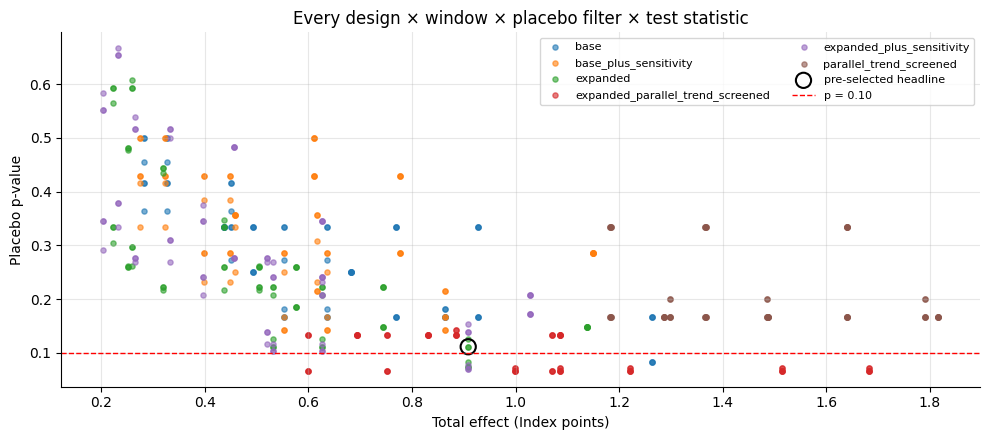

**Figure 3.** 432 specifications. The effect is positive in 100% of them (range +0.20 to +1.82), and 11.1% reach p ≤ 0.10. The direction is robust; separation from rival-brand drift is borderline.

In [8]:
curve = pd.read_parquet(T + "specification_curve.parquet")
fig, ax = plt.subplots(figsize=(10, 4.5))
for pool_name, group in curve.groupby("donor_pool"):
    ax.scatter(group["lift_index_points"], group["p_value"], s=14, alpha=0.6, label=pool_name)
prim = curve[curve["is_primary"]]
ax.scatter(prim["lift_index_points"], prim["p_value"], s=120, facecolors="none", edgecolors="black", lw=1.5, label="pre-selected headline")
ax.axhline(0.10, color="red", ls="--", lw=1, label="p = 0.10")
ax.set_xlabel("Total effect (Index points)"); ax.set_ylabel("Placebo p-value")
ax.set_title("Every design × window × placebo filter × test statistic"); ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()
s = est["specification_curve_summary"]
md(f"**Figure 3.** {s['specifications']} specifications. The effect is positive in {100*s['share_lift_positive']:.0f}% of them "
   f"(range {fmt(s['lift_range_index_points'][0], signed=True)} to {fmt(s['lift_range_index_points'][1], signed=True)}), "
   f"and {100*s['share_p_at_or_below_alpha']:.1f}% reach p ≤ 0.10. The direction is robust; separation from rival-brand drift is borderline.")

In [9]:
windows = curve[curve["selected_design"] & curve["placebo_filter"].eq("none")].pivot_table(
    index="window", columns="statistic", values=["lift_index_points", "p_value"])
windows.columns = [f"{a} ({b})" for a, b in windows.columns]
display(windows.style.format(precision=3))
md("**Table 3.** Headline design by window and test statistic. 'mean_gap_over_pre_rmspe' is a secondary statistic targeting a sustained "
   "one-directional shift; only the ratio statistic on the full window is the pre-registered headline test.")

,lift_index_points (mean_gap_over_pre_rmspe),lift_index_points (rmspe_ratio),p_value (mean_gap_over_pre_rmspe),p_value (rmspe_ratio)
window,,,,
all_post,0.909,0.909,0.074,0.111
before_spring_2026_surge,0.531,0.531,0.111,0.222
excluding_spring_2026_surge,0.626,0.626,0.111,0.222


**Table 3.** Headline design by window and test statistic. 'mean_gap_over_pre_rmspe' is a secondary statistic targeting a sustained one-directional shift; only the ratio statistic on the full window is the pre-registered headline test.

### 5.4 Media-value weighting (broadcast-inclusive exposure, ADR-0028; original 2024 design)

In [10]:
mv = json.loads(Path(E + "sponsorship_counterfactual_v1/media_value_intensity_sensitivity.json").read_text())
display(pd.DataFrame([
    {"Weighting (weeks covered by media value)": "Media value (relative intensity, broadcast-inclusive)", "Mean gap (Index points)": mv["media_intensity_weighted_gap_index_points"]},
    {"Weighting (weeks covered by media value)": "Blinkfire FIFA impressions (digital)", "Mean gap (Index points)": mv["blinkfire_weighted_gap_same_window_index_points"]},
    {"Weighting (weeks covered by media value)": "Unweighted", "Mean gap (Index points)": mv["unweighted_mean_gap_same_window_index_points"]},
]).style.format({"Mean gap (Index points)": "{:+.3f}"}).hide(axis="index"))
coef = mv["timing_regression"]["coefficients"]["media_intensity_log_adstock_z"]
md(f"**Table 4.** {mv['window_start']} to {mv['window_end']}, original 11-donor design. Weeks with more broadcast-inclusive exposure do not show a larger gap "
   f"(timing coefficient {fmt(coef['estimate_index_points'], 3, True)} points per s.d., HAC s.e. {fmt(coef['hac_se'], 3)}): the effect looks cumulative "
   "rather than exposure-driven. Media-value dollar amounts are never used (P1).")

Weighting (weeks covered by media value),Mean gap (Index points)
"Media value (relative intensity, broadcast-inclusive)",+0.863
Blinkfire FIFA impressions (digital),+0.938
Unweighted,+0.806


**Table 4.** 2025-04-28 to 2026-03-30, original 11-donor design. Weeks with more broadcast-inclusive exposure do not show a larger gap (timing coefficient +0.018 points per s.d., HAC s.e. 0.104): the effect looks cumulative rather than exposure-driven. Media-value dollar amounts are never used (P1).

### 5.5 The spring 2026 category surge (a confounder)

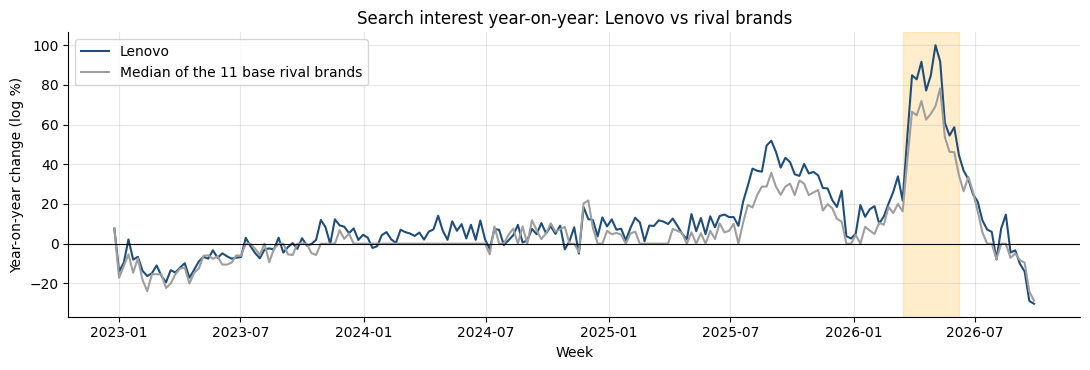

**Figure 4.** Orange band: spring 2026, when searches for every PC brand rose sharply year-on-year (consistent with the memory-shortage price rush). Lenovo reacts more strongly than rivals to such swings, so the gap in that period (+2.98 points over 12 weeks) is partly a category effect. Table 3 shows the effect excluding it.

In [11]:
base = registry.loc[registry["inclusion_policy"].eq("base"), "query_id"].tolist()
dp = donors.copy(); dp["week"] = pd.to_datetime(dp["week"])
pivot = dp[dp["query_id"].isin(base + ["anchor_lenovo"])].groupby(["week", "query_id"])["interest_common_scale"].mean().unstack()
yoy = 100 * np.log(pivot / pivot.shift(52))
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(yoy.index, yoy["anchor_lenovo"], label="Lenovo", color="#1f4e79")
ax.plot(yoy.index, yoy[base].median(axis=1), label="Median of the 11 base rival brands", color="#9e9e9e")
ax.axhline(0, color="black", lw=0.8); ax.axvspan(pd.Timestamp("2026-03-15"), pd.Timestamp("2026-06-07"), color="orange", alpha=0.2)
ax.set_ylabel("Year-on-year change (log %)"); ax.set_xlabel("Week"); ax.set_title("Search interest year-on-year: Lenovo vs rival brands")
ax.legend(); plt.tight_layout(); plt.show()
surge = table.set_index("Period").loc["Spring 2026 PC-price surge (confounded)"]
md(f"**Figure 4.** Orange band: spring 2026, when searches for every PC brand rose sharply year-on-year (consistent with the memory-shortage price rush). "
   f"Lenovo reacts more strongly than rivals to such swings, so the gap in that period ({fmt(surge['Mean gap (Index points)'], signed=True)} points over "
   f"{surge['Weeks']} weeks) is partly a category effect. Table 3 shows the effect excluding it.")

## 6. Interpretation

In [12]:
from srmp.experiments.brand_value_dominance_v1 import _salience_map
smap = _salience_map("data/curated/index/brand_index_weekly.parquet", "data/curated/trends/trends_weekly_averaged.parquet", "brand_lenovo")
pct = 100 * effect["lift_index_points"] / (effect["synthetic_post_mean_index"] - smap["zero_interest_index_level"])
ex = windows.loc["excluding_spring_2026_surge"]
md(f"""- **Headline:** over the sponsorship so far ({effect['post_weeks']} weeks, {effect['first_post_week']} to {effect['last_week']}), Lenovo's Brand Index is on average
  **{fmt(effect['lift_index_points'], signed=True)} points** above its no-sponsorship twin, about **{fmt(pct, 1, True)}% more brand search salience**
  (the Index is an exact linear function of search interest; zero searches = {fmt(smap['zero_interest_index_level'])}, twin level ≈ {fmt(effect['synthetic_post_mean_index'], 1)}).
- **Robustness:** positive in every one of {s['specifications']} specifications; {fmt(effect['leave_one_donor_out_range'][0], signed=True)} to
  {fmt(effect['leave_one_donor_out_range'][1], signed=True)} leaving out any one rival; {fmt(ex['lift_index_points (rmspe_ratio)'], signed=True)} excluding the spring 2026 surge.
- **Uncertainty:** the pre-registered placebo test gives p = {fmt(p['p_value'], 3)}, {'within' if p['p_value'] <= 0.10 else 'just outside'} the 0.10 threshold:
  {len(above)} of {p['placebos_kept']} rival brands drift as far from their own twins.
- **Decision relevance:** a consistent, plausibly sponsorship-related lift of about a tenth in brand salience, **borderline significant**. Report it with that
  qualifier; it becomes decision-grade if additional post-sponsorship weeks keep it in place and push the placebo test under 0.10.""")

- **Headline:** over the sponsorship so far (100 weeks, 2024-10-21 to 2026-09-14), Lenovo's Brand Index is on average
  **+0.91 points** above its no-sponsorship twin, about **+9.6% more brand search salience**
  (the Index is an exact linear function of search interest; zero searches = 80.61, twin level ≈ 90.1).
- **Robustness:** positive in every one of 432 specifications; +0.88 to
  +1.19 leaving out any one rival; +0.63 excluding the spring 2026 surge.
- **Uncertainty:** the pre-registered placebo test gives p = 0.111, just outside the 0.10 threshold:
  2 of 26 rival brands drift as far from their own twins.
- **Decision relevance:** a consistent, plausibly sponsorship-related lift of about a tenth in brand salience, **borderline significant**. Report it with that
  qualifier; it becomes decision-grade if additional post-sponsorship weeks keep it in place and push the placebo test under 0.10.

## 7. Limitations and non-claims

- **Search salience, not full brand equity.** The Brand Index does not measure awareness, consideration, preference or purchase directly.
- **Not proven causal.** The design is causal in intent, but with p above the threshold the lift is not distinguishable from normal relative drift among tech brands.
- **Confounding.** The spring 2026 PC-price surge, Lenovo-specific news (record results, share-price rally) and product launches fall inside the sponsorship period. Event controls and window exclusions reduce, but do not remove, their influence.
- **One treated brand, one realisation.** The design was chosen on pre-period fit; the post period cannot be replicated.
- **Donor screening is evidence-bounded.** "No FIFA sponsorship found" is not proof of none.
- **Provisional data.** The last two weeks of each Google Trends pull are excluded and the latest weeks will be revised.
- **Statistical vs unmodelled uncertainty.** The placebo p-value captures rival-brand drift, not Trends sampling error, index calibration error or screening mistakes.

## Next steps

1. Re-estimate after each data refresh; the next pull after 18 October 2026 adds the full World Cup persistence window.
2. Test the effect on survey-based brand metrics with the GWI Q2/Q3 2026 waves.
3. Keep this notebook synchronized: `python -m srmp.review` after every rebuild.